In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import CONSTANT as cons

In [2]:
# Load a single eeg parquet file
df1 = pd.read_parquet(cons.PATH_TO_FILES_TRAIN_EEG+'/568657.parquet')

In [ ]:
# Basic Shape & Structure

print(f"Shape: {df1.shape}")
print(f"  -> {df1.shape[0]:,} rows (time samples)")
print(f"  -> {df1.shape[1]} columns (electrodes/channels)")

print("\nColumn names:")
print(list(df1.columns))

print("\nData types per column:")
print(df1.dtypes)

Shape: (13200, 20)
  -> 13,200 rows (time samples)
  -> 20 columns (electrodes/channels)

Column names:
['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']

Data types per column:
Fp1    float32
F3     float32
C3     float32
P3     float32
F7     float32
T3     float32
T5     float32
O1     float32
Fz     float32
Cz     float32
Pz     float32
Fp2    float32
F4     float32
C4     float32
P4     float32
F8     float32
T4     float32
T6     float32
O2     float32
EKG    float32
dtype: object


In [ ]:
# Memory & Overall Info
df1.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Fp1     13200 non-null  float32
 1   F3      13200 non-null  float32
 2   C3      13200 non-null  float32
 3   P3      13200 non-null  float32
 4   F7      13200 non-null  float32
 5   T3      13200 non-null  float32
 6   T5      13200 non-null  float32
 7   O1      13200 non-null  float32
 8   Fz      13200 non-null  float32
 9   Cz      13200 non-null  float32
 10  Pz      13200 non-null  float32
 11  Fp2     13200 non-null  float32
 12  F4      13200 non-null  float32
 13  C4      13200 non-null  float32
 14  P4      13200 non-null  float32
 15  F8      13200 non-null  float32
 16  T4      13200 non-null  float32
 17  T6      13200 non-null  float32
 18  O2      13200 non-null  float32
 19  EKG     13200 non-null  float32
dtypes: float32(20)
memory usage: 1.0 MB


In [5]:
# Peek at the actual values
print("First 5 rows:")
display(df1.head())

print("\nLast 5 rows:")
display(df1.tail())

print("\nRandom 5 rows (often more informative than head/tail):")
display(df1.sample(5, random_state=42))

First 5 rows:


,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
0,-75.360001,86.379997,65.470001,62.580002,170.350006,92.370003,39.68,89.870003,18.260000,-28.440001,-15.190000,16.93,13.81,-42.160000,78.099998,-143.649994,121.239998,-1.470000,72.550003,-3090.090088
1,-107.739998,53.139999,32.590000,21.950001,140.500000,59.070000,4.26,53.310001,-18.490000,-63.270000,-52.110001,-13.23,-16.42,-80.430000,64.449997,-168.500000,88.400002,-28.520000,40.250000,5560.439941
2,-103.050003,46.330002,10.750000,9.150000,137.820007,50.950001,-3.50,45.070000,-20.879999,-66.629997,-69.750000,-9.20,-21.40,-93.089996,5.120000,-176.089996,51.689999,-38.639999,31.820000,-4161.450195
3,-75.099998,77.870003,40.150002,31.790001,166.630005,76.769997,17.99,67.650002,11.140000,-32.950001,-38.509998,14.77,9.79,-66.480003,48.220001,-147.990005,86.629997,-18.639999,62.509998,31769.970703
4,-97.919998,58.209999,27.330000,5.340000,144.080002,47.200001,-10.43,40.250000,-12.350000,-52.500000,-54.919998,-10.07,-8.04,-90.820000,67.269997,-164.710007,80.680000,-36.520000,41.830002,6879.720215



Last 5 rows:


,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
13195,-160.800003,-114.349998,-129.779999,-59.860001,-166.770004,-55.310001,-61.900002,-66.510002,-40.220001,-44.689999,-126.870003,-119.510002,-89.480003,-176.240005,1.300000,-161.649994,-6.820000,102.620003,-46.330002,2097.229980
13196,-169.919998,-132.699997,-154.160004,-69.129997,-184.130005,-77.470001,-75.959999,-75.910004,-54.389999,-57.410000,-140.020004,-127.639999,-107.169998,-191.160004,-60.020000,-181.389999,-40.779999,92.239998,-59.740002,1954.630005
13197,-141.600006,-99.709999,-120.599998,-28.770000,-154.869995,-47.549999,-41.610001,-36.299999,-22.420000,-16.940001,-94.050003,-100.709999,-75.910004,-145.940002,-26.469999,-152.240005,2.190000,120.709999,-19.320000,-3010.149902
13198,-155.550003,-105.559998,-116.540001,-31.240000,-163.490005,-60.480000,-51.320000,-43.490002,-34.860001,-22.889999,-84.669998,-116.760002,-77.989998,-138.279999,23.129999,-149.500000,28.150000,118.300003,-21.100000,280.119995
13199,-184.429993,-145.580002,-161.080002,-66.150002,-202.330002,-107.309998,-92.260002,-77.970001,-72.849998,-54.849998,-120.160004,-145.029999,-108.199997,-169.899994,-35.790001,-181.940002,-15.490000,90.540001,-55.959999,3064.830078



Random 5 rows (often more informative than head/tail):


,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
4111,49.230000,-272.790009,11.340000,15.700000,-204.330002,34.270000,59.509998,31.600000,122.540001,-40.730000,47.970001,347.739990,496.029999,452.440002,375.239990,134.410004,434.739990,249.300003,75.540001,5750.520020
10607,-12.830000,-41.869999,49.560001,78.480003,-32.549999,4.230000,73.540001,109.730003,29.629999,-47.020000,-22.139999,9.100000,78.389999,-23.809999,159.830002,-29.270000,209.690002,97.339996,197.979996,-2572.260010
7372,-93.419998,-15.320000,80.760002,-17.680000,53.590000,-25.809999,-62.740002,-39.950001,-36.439999,-33.310001,-73.370003,-44.060001,-90.260002,-150.470001,0.520000,-153.410004,-11.810000,-58.200001,8.520000,1313.199951
11786,-65.040001,-71.989998,89.139999,21.280001,-33.680000,-22.639999,-18.110001,43.900002,-29.809999,-25.280001,-20.139999,-18.969999,45.910000,20.809999,135.460007,-51.939999,119.800003,10.480000,85.360001,167.139999
12227,-57.230000,-129.389999,-184.029999,-47.049999,-103.480003,-48.900002,-76.620003,1.770000,-35.439999,-47.299999,-98.059998,-13.900000,-120.360001,-169.089996,-95.570000,-92.809998,-166.410004,-8.090000,16.879999,-5514.129883


In [ ]:
# Summary Statistics
display(df1.describe().T)  # .T transposes so each electrode is a row

,count,mean,std,min,25%,50%,75%,max
Fp1,13200.0,-83.688431,85.145210,-517.090027,-134.124996,-85.800003,-31.347500,633.109985
F3,13200.0,-70.744354,76.254784,-449.670013,-115.120003,-72.169998,-25.827500,416.410004
C3,13200.0,-38.940075,111.118355,-486.320007,-111.932499,-39.180000,37.507500,421.750000
P3,13200.0,-39.293427,92.085815,-428.839996,-94.359999,-38.910000,16.379999,538.830017
F7,13200.0,-99.546005,110.948250,-742.530029,-162.009995,-95.869999,-27.302500,560.030029
T3,13200.0,-39.795822,89.747498,-512.359985,-89.222502,-41.825001,12.775000,694.369995
T5,13200.0,-78.729050,106.698647,-655.609985,-141.990005,-78.459999,-15.032500,627.080017
O1,13200.0,-46.548851,116.029404,-468.459991,-118.512501,-48.090000,25.842500,423.850006
Fz,13200.0,-18.649786,51.055901,-199.679993,-50.804999,-22.510000,7.237500,389.709991
Cz,13200.0,-32.257042,40.734814,-298.980011,-56.082501,-32.065001,-7.430000,149.679993


In [7]:
# Missing Values
missing_count = df1.isna().sum()
missing_pct = (df1.isna().mean() * 100).round(2)

print("Missing values per column:")
print(pd.DataFrame({'count': missing_count, 'percent': missing_pct}))

Missing values per column:
     count  percent
Fp1      0      0.0
F3       0      0.0
C3       0      0.0
P3       0      0.0
F7       0      0.0
T3       0      0.0
T5       0      0.0
O1       0      0.0
Fz       0      0.0
Cz       0      0.0
Pz       0      0.0
Fp2      0      0.0
F4       0      0.0
C4       0      0.0
P4       0      0.0
F8       0      0.0
T4       0      0.0
T6       0      0.0
O2       0      0.0
EKG      0      0.0


In [8]:
SAMPLING_RATE = 200  # Hz - standard for HMS dataset (also hardcoded in filters.py)

n_samples = len(df1)
duration_seconds = n_samples / SAMPLING_RATE
duration_minutes = duration_seconds / 60

print(f"Index type: {type(df1.index).__name__}")
print(f"Index range: {df1.index.min()} to {df1.index.max()}")
print(f"Number of samples: {n_samples:,}")
print(f"Sampling rate: {SAMPLING_RATE} Hz (samples per second)")
print(f"Time between consecutive samples: {1000/SAMPLING_RATE:.2f} ms")
print(f"Total duration: {duration_seconds:.2f} seconds  ({duration_minutes:.2f} minutes)")

Index type: RangeIndex
Index range: 0 to 13199
Number of samples: 13,200
Sampling rate: 200 Hz (samples per second)
Time between consecutive samples: 5.00 ms
Total duration: 66.00 seconds  (1.10 minutes)


In [ ]:
# Verify Sampling Rate Against train.csv
train = pd.read_csv(cons.PATH_TO_TRAIN_CSV)
this_eeg = train[train['eeg_id'] == 568657]
display(this_eeg)

print(f"\nNumber of 50-sec windows for this patient: {len(this_eeg)}")
print(f"Parquet file samples: {len(df1):,}")
print(f"If sampling rate is 200 Hz, that equals {len(df1)/200:.1f} seconds of recording")

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
40927,568657,0,0.0,789577333,0,0.0,1825637311,20654,Other,0,0,3,0,2,7
40928,568657,1,6.0,789577333,1,6.0,3640441665,20654,Other,0,0,3,0,2,7
40929,568657,2,12.0,789577333,2,12.0,1364530340,20654,Other,0,0,3,0,2,7
40930,568657,3,16.0,789577333,3,16.0,1874525225,20654,Other,0,0,3,0,2,7



Number of 50-sec windows for this patient: 4
Parquet file samples: 13,200
If sampling rate is 200 Hz, that equals 66.0 seconds of recording


In [ ]:
# Per-Electrode Range (Artifact Detection)
ranges = df1.agg(['min', 'max', 'mean', 'std']).T
ranges['range'] = ranges['max'] - ranges['min']
display(ranges.sort_values('range', ascending=False))

print("\nSamples with |value| > 500 µV (likely artifacts) per channel:")
print((df1.abs() > 500).sum())

,min,max,mean,std,range
EKG,-11014.259766,33402.828125,2209.949951,8021.297363,44417.085938
F7,-742.530029,560.030029,-99.546005,110.948250,1302.560059
T5,-655.609985,627.080017,-78.729050,106.698647,1282.689941
T3,-512.359985,694.369995,-39.795822,89.747498,1206.729980
Fp2,-466.730011,739.789978,-20.703747,87.899582,1206.520020
T4,-514.039978,684.070007,0.114057,142.147400,1198.109985
F8,-517.719971,674.940002,-115.719391,99.639526,1192.659912
Fp1,-517.090027,633.109985,-83.688431,85.145210,1150.199951
P4,-670.679993,417.429993,-29.564924,146.680634,1088.109985
P3,-428.839996,538.830017,-39.293427,92.085815,967.670044



Samples with |value| > 500 µV (likely artifacts) per channel:
Fp1       17
F3         0
C3         0
P3         4
F7        22
T3        20
T5        31
O1         0
Fz         0
Cz         0
Pz         0
Fp2       16
F4         3
C4         0
P4       124
F8        18
T4        29
T6         1
O2         0
EKG    12333
dtype: int64


## Are Any Columns Constant or Duplicated?

In [12]:
print("Number of unique values per column:")
print(df1.nunique())

print("\nAre any columns identical to another?")
print(df1.T.duplicated().sum(), "duplicate columns found")

Number of unique values per column:
Fp1    10491
F3     10273
C3     11211
P3     10750
F7     11057
T3     10653
T5     10966
O1     11238
Fz      9179
Cz      8559
Pz     10223
Fp2    10498
F4     10757
C4     10375
P4     11618
F8     10912
T4     11574
T6     11026
O2     11275
EKG    13135
dtype: int64

Are any columns identical to another?
0 duplicate columns found


## Quick Visual Sanity Check

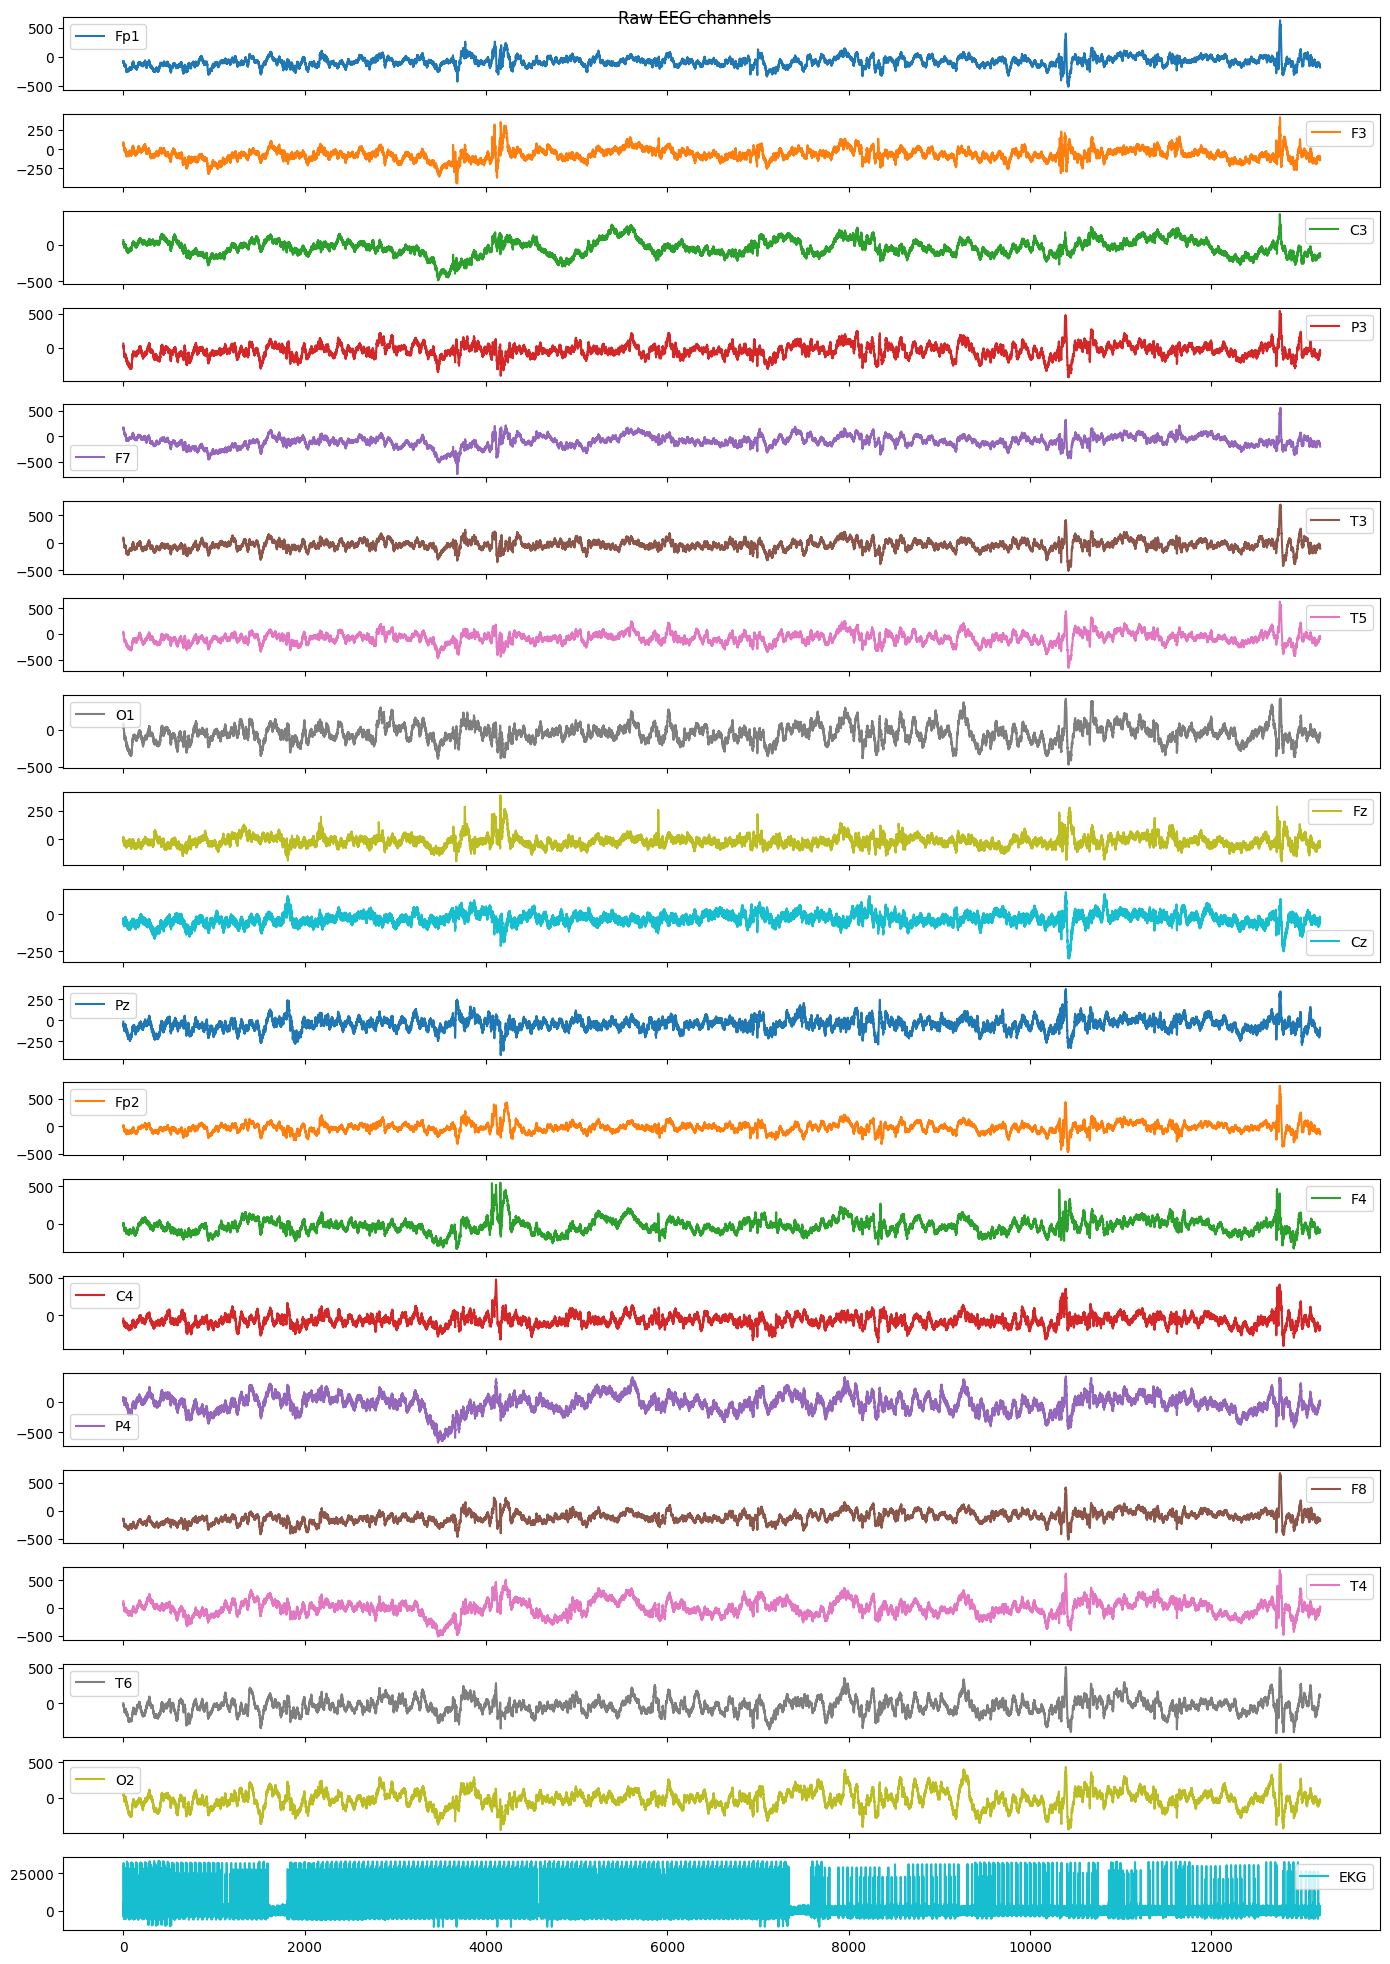

In [13]:
df1.plot(subplots=True, figsize=(14, 20), sharex=True, title="Raw EEG channels")
plt.tight_layout()
plt.show()